/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_86880/2923918940.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)


Datei erfolgreich geladen: ../data/raw/rechts_andre.m4a
Abtastrate: 48000 Hz
Dauer: 31.93 Sekunden


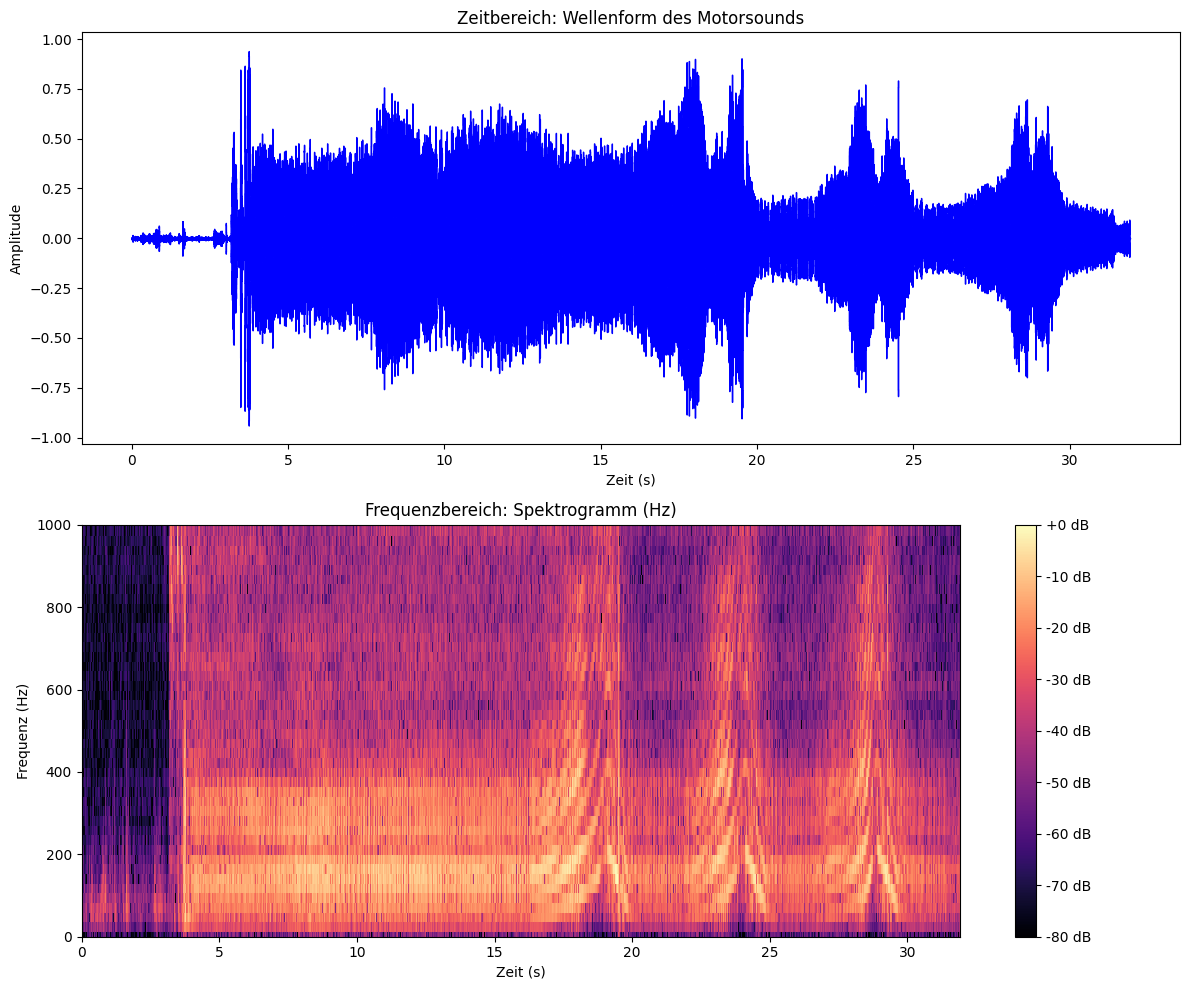

In [29]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Datei laden
file_path = '../data/raw/rechts_andre.m4a'
# sr=None behält die original Abtastrate bei (meist 44.1kHz oder 48kHz)
y, sr = librosa.load(file_path, sr=None)

print(f"Datei erfolgreich geladen: {file_path}")
print(f"Abtastrate: {sr} Hz")
print(f"Dauer: {len(y)/sr:.2f} Sekunden")

# 2. Plotting vorbereiten
plt.figure(figsize=(12, 10))

# --- Zeitbereich (Waveform) ---
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title('Zeitbereich: Wellenform des Motorsounds')
plt.xlabel('Zeit (s)')
plt.ylabel('Amplitude')

# --- Frequenzbereich (Spektrogramm) ---
# Wir nutzen eine Kurzzeit-Fourier-Transformation (STFT)
D = librosa.stft(y)  # STFT berechnen
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max) # In Dezibel umrechnen

plt.subplot(2, 1, 2)
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(img, format='%+2.0f dB')
plt.title('Frequenzbereich: Spektrogramm (Hz)')
plt.ylim(0, 1000)  # Fokus auf den Bereich bis 15kHz (relevante Mechanik)
plt.xlabel('Zeit (s)')
plt.ylabel('Frequenz (Hz)')

plt.tight_layout()
plt.show()

# Vergleich André und Philip

In [30]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# 1. Parameter optimiert für 24kHz
START_SEC = 4
DURATION_SEC = 3
TARGET_SR = 24000
N_MELS = 256        # Reduziert von 512, um die "Empty filters" Warnung zu beheben
HOP_LENGTH = 16
N_FFT = 1024

def load_slice_mel(file_path):
    # 'sr=TARGET_SR' sorgt für konsistente Daten
    y, sr = librosa.load(file_path, sr=TARGET_SR, offset=START_SEC, duration=DURATION_SEC)
    
    # n_mels=256 ist bei 24kHz SR das Maximum für saubere Filter
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, 
                                       n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

# 2. Daten laden
path_andre = '../data/raw/rechts_andre.m4a'
path_philip = '../data/raw/rechts_philip.m4a'

mel_andre = load_slice_mel(path_andre)
mel_philip = load_slice_mel(path_philip)

min_width = min(mel_andre.shape[1], mel_philip.shape[1])
mel_andre = mel_andre[:, :min_width]
mel_philip = mel_philip[:, :min_width]
mel_diff = np.abs(mel_andre - mel_philip)

/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_86880/1561781138.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=TARGET_SR, offset=START_SEC, duration=DURATION_SEC)


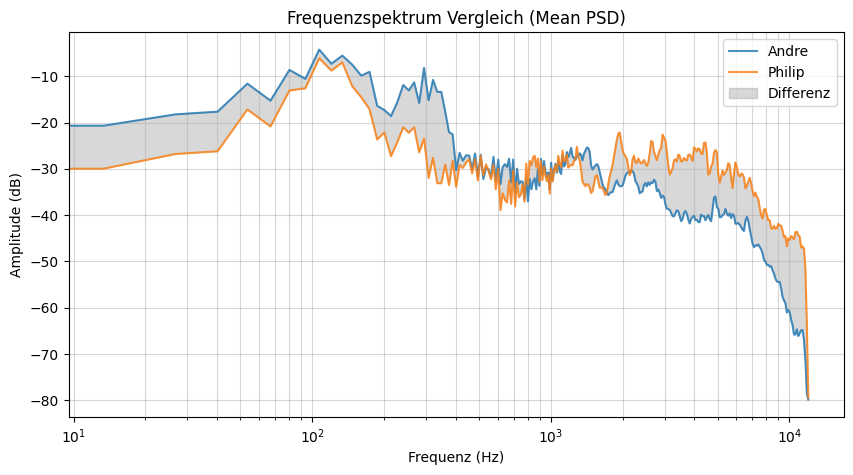

In [31]:
plt.figure(figsize=(10, 5))
# Mittelwert über die Zeitachse (axis=1)
mean_andre = np.mean(mel_andre, axis=1)
mean_philip = np.mean(mel_philip, axis=1)

# Frequenzachse für den Plot erstellen
freqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=TARGET_SR/2)

plt.plot(freqs, mean_andre, label='Andre', alpha=0.8)
plt.plot(freqs, mean_philip, label='Philip', alpha=0.8)
plt.fill_between(freqs, mean_andre, mean_philip, color='gray', alpha=0.3, label='Differenz')

plt.xscale('log') # Logarithmisch sieht man die Unterschiede besser
plt.title('Frequenzspektrum Vergleich (Mean PSD)')
plt.xlabel('Frequenz (Hz)')
plt.ylabel('Amplitude (dB)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Optimaler Time-Lag: -2284 Frames (ca. -1.523 Sekunden)


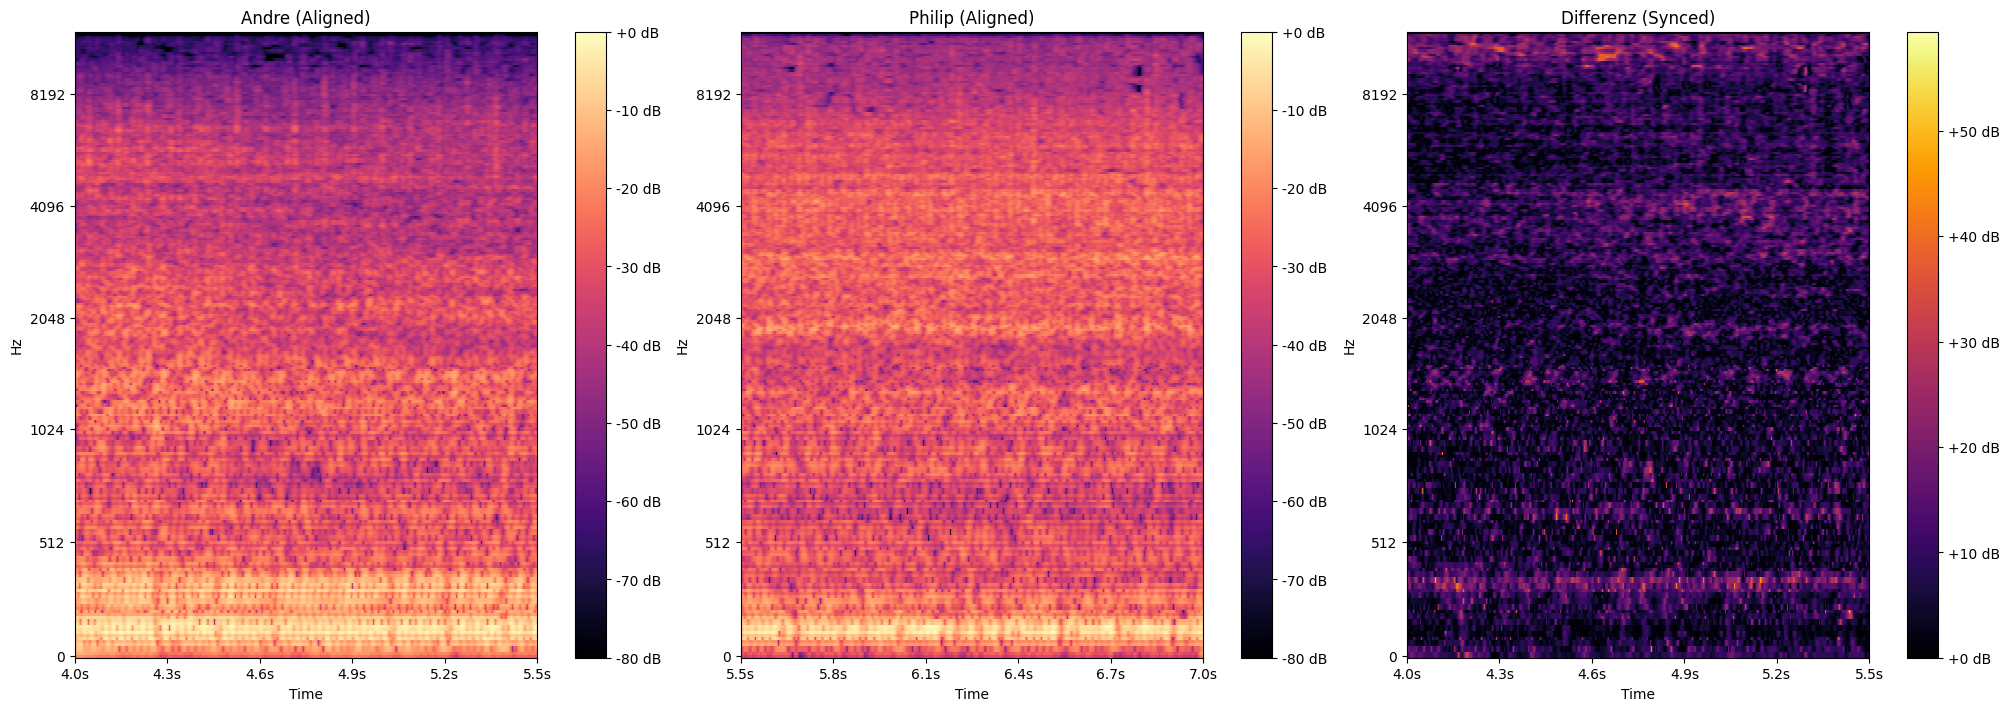

In [32]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.signal import correlate

# --- 1. Synchronisations-Logik ---
def synchronize_signals(spec_a, spec_b):
    # Mittlere Energie über alle Frequenzen (Rhythmus-Extraktion)
    env_a = np.mean(spec_a, axis=0)
    env_b = np.mean(spec_b, axis=0)
    
    # Zero-mean Normalisierung für bessere Korrelation
    env_a = env_a - np.mean(env_a)
    env_b = env_b - np.mean(env_b)
    
    # Kreuzkorrelation
    corr = correlate(env_a, env_b, mode='full')
    lag = np.argmax(corr) - (len(env_b) - 1)
    return lag

# Lag berechnen (basierend auf deinen bereits geladenen mel_andre / mel_philip)
lag = synchronize_signals(mel_andre, mel_philip)
lag_sec = lag * HOP_LENGTH / TARGET_SR
print(f"Optimaler Time-Lag: {lag} Frames (ca. {lag_sec:.3f} Sekunden)")

# Signale verschieben und zuschneiden
if lag > 0:
    mel_andre_sync = mel_andre[:, lag:]
    mel_philip_sync = mel_philip[:, :-lag]
    actual_start_philip = START_SEC
    actual_start_andre = START_SEC + lag_sec
elif lag < 0:
    lag_abs = abs(lag)
    mel_andre_sync = mel_andre[:, :-lag_abs]
    mel_philip_sync = mel_philip[:, lag_abs:]
    actual_start_philip = START_SEC + abs(lag_sec)
    actual_start_andre = START_SEC
else:
    mel_andre_sync, mel_philip_sync = mel_andre.copy(), mel_philip.copy()
    actual_start_philip = actual_start_andre = START_SEC

# Neue Dauer berechnen
new_duration = mel_andre_sync.shape[1] * HOP_LENGTH / TARGET_SR
mel_diff_sync = np.abs(mel_andre_sync - mel_philip_sync)

# --- 2. Visualisierung ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

norm = Normalize(vmin=min(mel_andre_sync.min(), mel_philip_sync.min()), 
                 vmax=max(mel_andre_sync.max(), mel_philip_sync.max()))

def plot_spec_dynamic(data, title, ax, start_time, duration, norm_obj=None, cmap='magma'):
    img = librosa.display.specshow(data, sr=TARGET_SR, hop_length=HOP_LENGTH, 
                                   x_axis='time', y_axis='mel', 
                                   ax=ax, norm=norm_obj, cmap=cmap)
    ax.set_title(title)
    
    # Zeitachse mit Dezimalstellen beschriften (angepasst an neuen Startwert)
    tick_positions = np.linspace(0, duration, 6)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{(x + start_time):.1f}s" for x in tick_positions])
    return img

# Plots erstellen
img1 = plot_spec_dynamic(mel_andre_sync, 'Andre (Aligned)', axes[0], actual_start_andre, new_duration, norm)
img2 = plot_spec_dynamic(mel_philip_sync, 'Philip (Aligned)', axes[1], actual_start_philip, new_duration, norm)
img3 = plot_spec_dynamic(mel_diff_sync, 'Differenz (Synced)', axes[2], actual_start_andre, new_duration, cmap='inferno')

fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')
fig.colorbar(img3, ax=axes[2], format='%+2.0f dB')

plt.show()

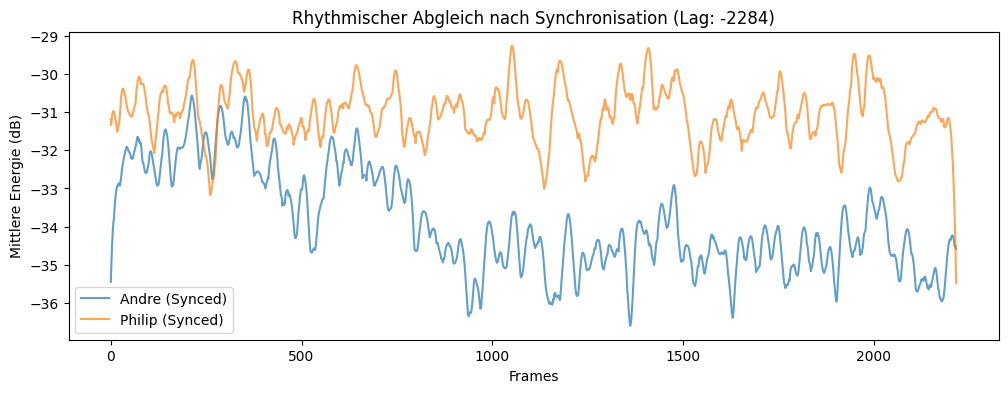

In [33]:
# Nur zur Kontrolle: Envelopes visualisieren
env_andre = np.mean(mel_andre_sync, axis=0)
env_philip = np.mean(mel_philip_sync, axis=0)

plt.figure(figsize=(12, 4))
plt.plot(env_andre, label='Andre (Synced)', alpha=0.7)
plt.plot(env_philip, label='Philip (Synced)', alpha=0.7)
plt.title(f'Rhythmischer Abgleich nach Synchronisation (Lag: {lag})')
plt.xlabel('Frames')
plt.ylabel('Mittlere Energie (dB)')
plt.legend()
plt.show()

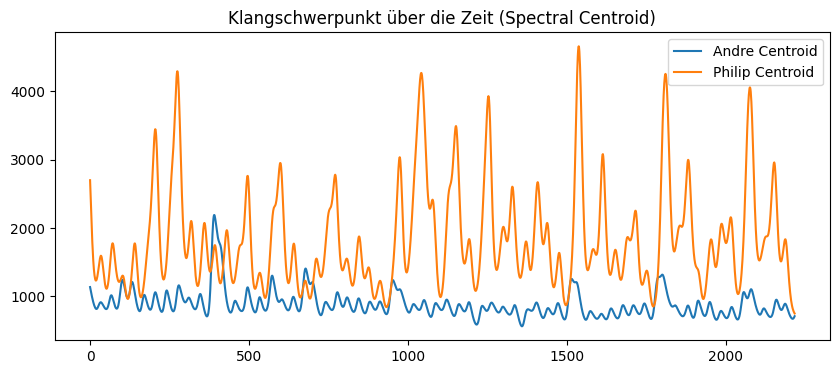

In [34]:
# Beispiel-Code für den Spectral Centroid
centroid_andre = librosa.feature.spectral_centroid(S=librosa.db_to_power(mel_andre_sync))[0]
centroid_philip = librosa.feature.spectral_centroid(S=librosa.db_to_power(mel_philip_sync))[0]

plt.figure(figsize=(10, 4))
plt.plot(centroid_andre, label='Andre Centroid')
plt.plot(centroid_philip, label='Philip Centroid')
plt.title('Klangschwerpunkt über die Zeit (Spectral Centroid)')
plt.legend()
plt.show()

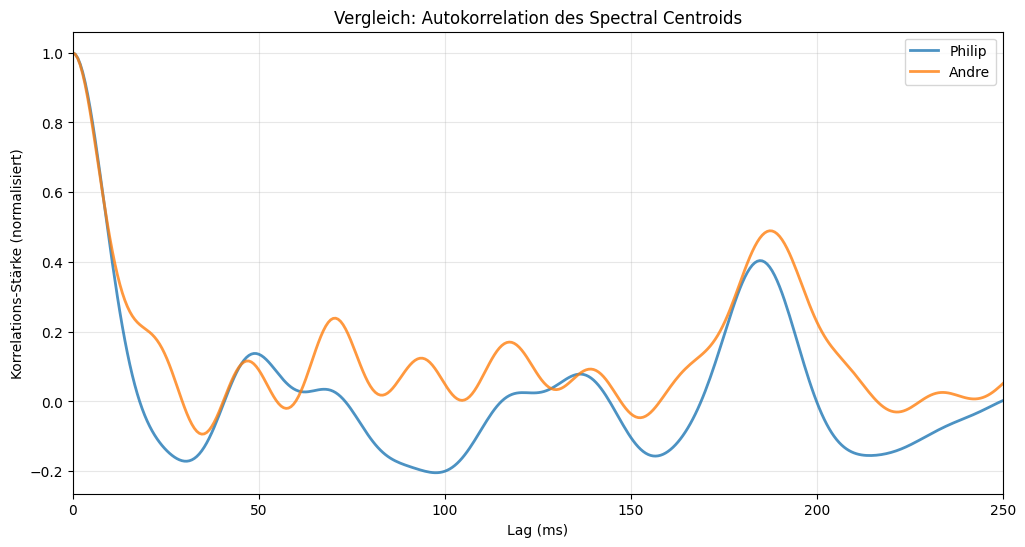

Philip - Dominanter Rhythmus-Peak: 184.67 ms (entspricht ca. 325 bpm / u/min)
Andre  - Dominanter Rhythmus-Peak: 187.33 ms (entspricht ca. 320 bpm / u/min)


In [35]:
from scipy.signal import correlate

# 1. Daten vorbereiten (Zentrieren, um Bias zu vermeiden)
c_philip = centroid_philip - np.mean(centroid_philip)
c_andre = centroid_andre - np.mean(centroid_andre)

# 2. Autokorrelation berechnen für beide
# Philip
auto_corr_p = correlate(c_philip, c_philip, mode='full')
auto_corr_p = auto_corr_p[len(auto_corr_p)//2:]

# Andre
auto_corr_a = correlate(c_andre, c_andre, mode='full')
auto_corr_a = auto_corr_a[len(auto_corr_a)//2:]

# 3. Zeitachse für die Korrelation (in Millisekunden)
# Da beide auf denselben Parametern basieren, reicht eine Zeitachse
time_lags = np.arange(len(auto_corr_p)) * (HOP_LENGTH / TARGET_SR)

# 4. Plotten (Vergleich im selben Graph)
plt.figure(figsize=(12, 6))
plt.plot(time_lags * 1000, auto_corr_p / np.max(auto_corr_p), label='Philip', alpha=0.8, linewidth=2)
plt.plot(time_lags * 1000, auto_corr_a / np.max(auto_corr_a), label='Andre', alpha=0.8, linewidth=2)

plt.title('Vergleich: Autokorrelation des Spectral Centroids')
plt.xlabel('Lag (ms)')
plt.ylabel('Korrelations-Stärke (normalisiert)')
plt.xlim(0, 250) # Fokus auf Leerlauf-Bereich bis 250ms
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Peaks finden (außer dem Peak bei 0ms)
def get_main_peak(corr_data, lags):
    # Wir überspringen die ersten 10-15ms, um nicht den Start-Peak zu fangen
    min_lag_idx = int(0.015 * TARGET_SR / HOP_LENGTH) 
    peak_idx = np.argmax(corr_data[min_lag_idx:]) + min_lag_idx
    return lags[peak_idx] * 1000

peak_p = get_main_peak(auto_corr_p, time_lags)
peak_a = get_main_peak(auto_corr_a, time_lags)

print(f"Philip - Dominanter Rhythmus-Peak: {peak_p:.2f} ms (entspricht ca. {60000/(peak_p):.0f} bpm / u/min)")
print(f"Andre  - Dominanter Rhythmus-Peak: {peak_a:.2f} ms (entspricht ca. {60000/(peak_a):.0f} bpm / u/min)")

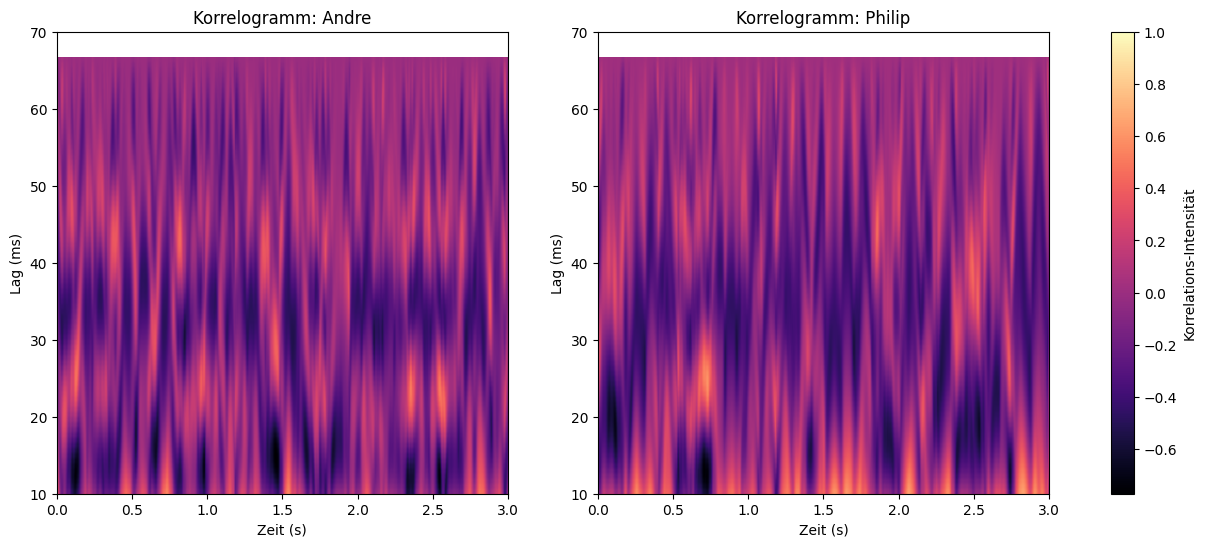

In [36]:
def plot_correlogram(spec_data, title, ax):
    # Parameter für das Korrelogramm
    win_size = 100  # Wie viele Frames schauen wir uns pro Fenster an
    step_size = 5   # Schrittweite für das Schiebefenster
    
    num_steps = (spec_data.shape[1] - win_size) // step_size
    correlogram = []

    for i in range(num_steps):
        start = i * step_size
        end = start + win_size
        # Ausschnitt des Spektrogramms (Envelope)
        segment = np.mean(spec_data[:, start:end], axis=0)
        segment -= np.mean(segment)
        
        # Autokorrelation für diesen Ausschnitt
        corr = correlate(segment, segment, mode='full')
        corr = corr[len(corr)//2:]
        correlogram.append(corr / np.max(corr))

    correlogram = np.array(correlogram).T
    
    # Plotten
    img = ax.imshow(correlogram, aspect='auto', origin='lower', cmap='magma',
                    extent=[0, DURATION_SEC, 0, win_size * (HOP_LENGTH / TARGET_SR) * 1000])
    ax.set_title(title)
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Lag (ms)')
    ax.set_ylim(10, 70) # Fokus auf den relevanten Bereich
    return img

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

img1 = plot_correlogram(mel_andre_sync, 'Korrelogramm: Andre', axes[0])
img2 = plot_correlogram(mel_philip_sync, 'Korrelogramm: Philip', axes[1])

fig.colorbar(img1, ax=axes, label='Korrelations-Intensität')
plt.show()

/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_86880/3083502502.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=TARGET_SR)
/opt/anaconda3/envs/s1000-diagnoser/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


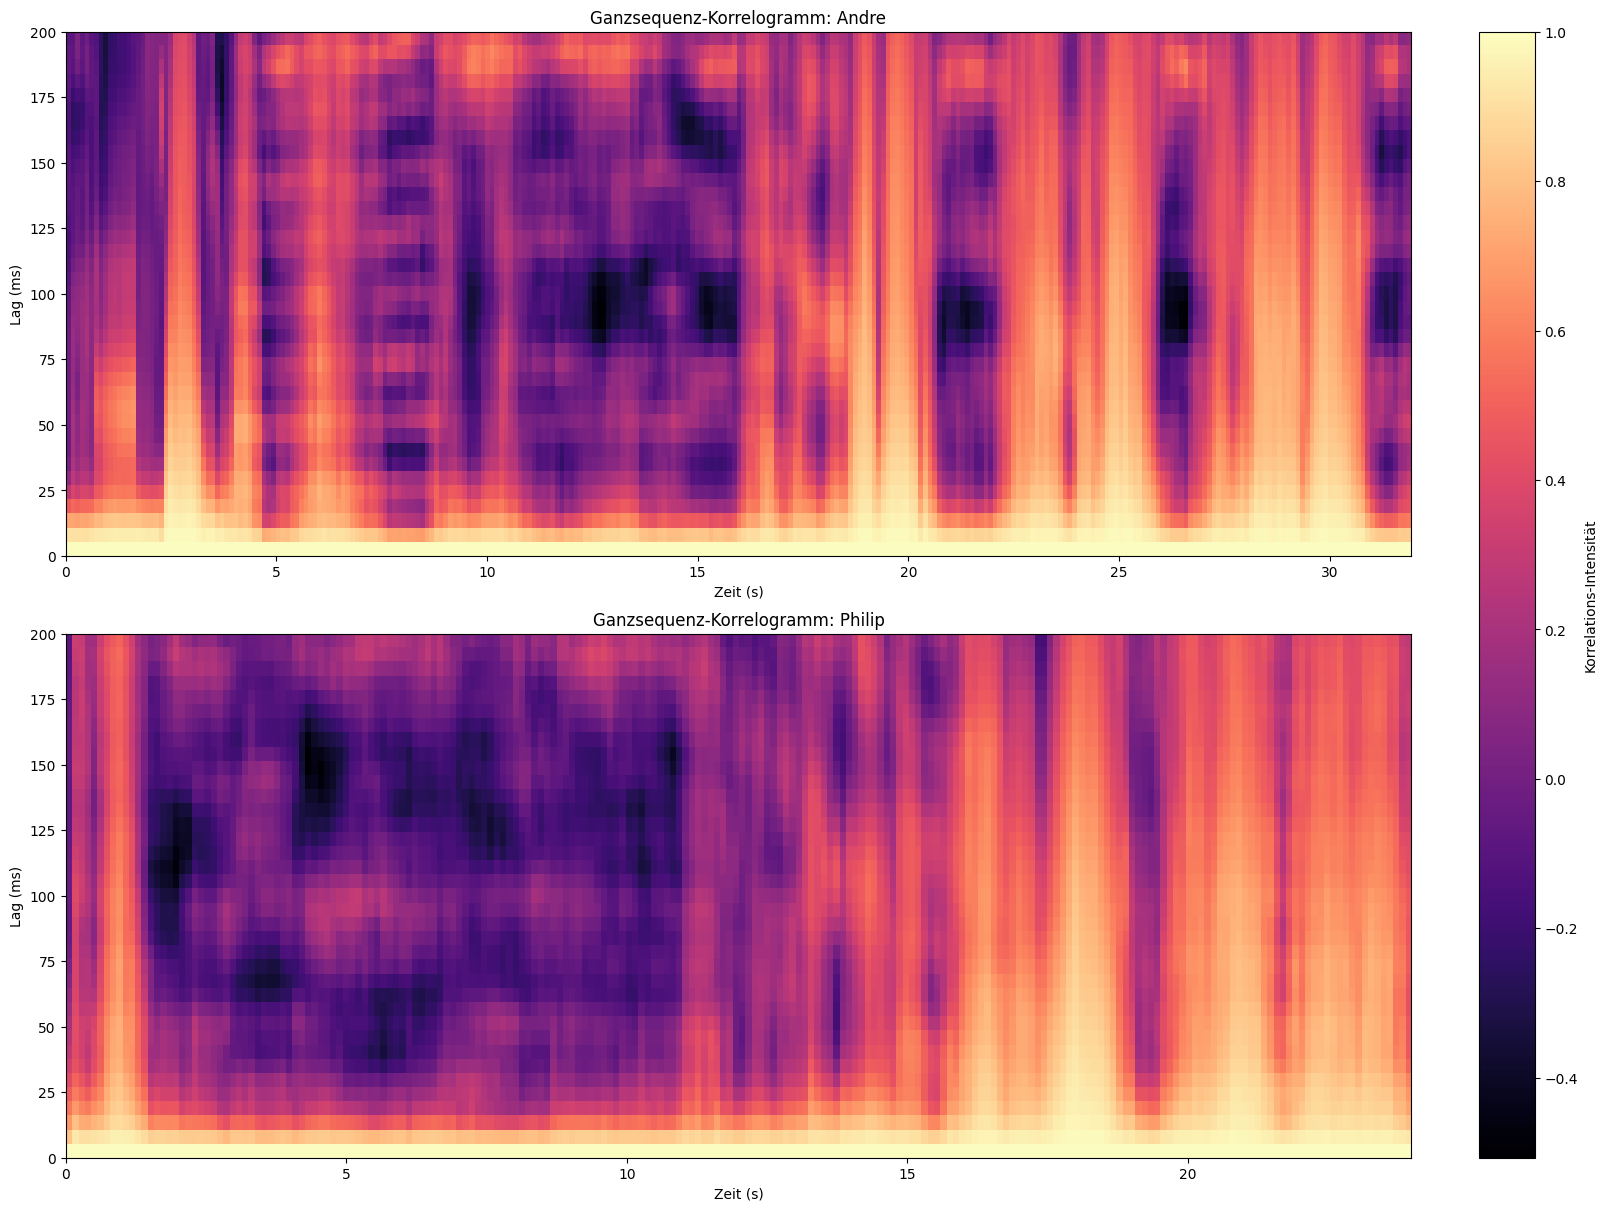

In [37]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import correlate

# 1. Parameter für die gesamte Sequenz
TARGET_SR = 24000
HOP_LENGTH = 128
N_MELS = 256
N_FFT = 1024

def process_full_correlogram(file_path):
    # Die ganze Datei laden (ohne offset/duration)
    y, sr = librosa.load(file_path, sr=TARGET_SR)
    duration = len(y) / sr
    
    # Mel-Spektrogramm für die ganze Länge
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Korrelogramm berechnen
    win_size = 200  # Etwas größeres Fenster für mehr Stabilität beim Sweep
    step_size = 20  # Größere Schritte für schnellere Berechnung bei langen Files
    
    num_steps = (S_db.shape[1] - win_size) // step_size
    correlogram = []

    for i in range(num_steps):
        start = i * step_size
        end = start + win_size
        segment = np.mean(S_db[:, start:end], axis=0)
        segment -= np.mean(segment)
        
        corr = correlate(segment, segment, mode='full')
        corr = corr[len(corr)//2:]
        # Normalisierung pro Zeitschritt (lokale Normalisierung)
        if np.max(corr) > 0:
            correlogram.append(corr / np.max(corr))
        else:
            correlogram.append(corr)

    return np.array(correlogram).T, duration

# 2. Daten verarbeiten
path_andre = '../data/raw/rechts_andre.m4a'
path_philip = '../data/raw/rechts_philip.m4a'

corr_a, dur_a = process_full_correlogram(path_andre)
corr_p, dur_p = process_full_correlogram(path_philip)

# 3. Visualisierung
fig, axes = plt.subplots(2, 1, figsize=(16, 12), constrained_layout=True)

# Wir limitieren den Lag auf 200ms (reicht für alles über 300 u/min)
max_lag_ms = 200
max_lag_idx = int(max_lag_ms / (1000 * HOP_LENGTH / TARGET_SR))

def plot_full_corr(data, title, ax, duration):
    img = ax.imshow(data[:max_lag_idx, :], aspect='auto', origin='lower', cmap='magma',
                    extent=[0, duration, 0, max_lag_ms])
    ax.set_title(title)
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Lag (ms)')
    return img

img1 = plot_full_corr(corr_a, 'Ganzsequenz-Korrelogramm: Andre', axes[0], dur_a)
img2 = plot_full_corr(corr_p, 'Ganzsequenz-Korrelogramm: Philip', axes[1], dur_p)

fig.colorbar(img1, ax=axes, label='Korrelations-Intensität')
plt.show()

## Drehzahl extrahieren

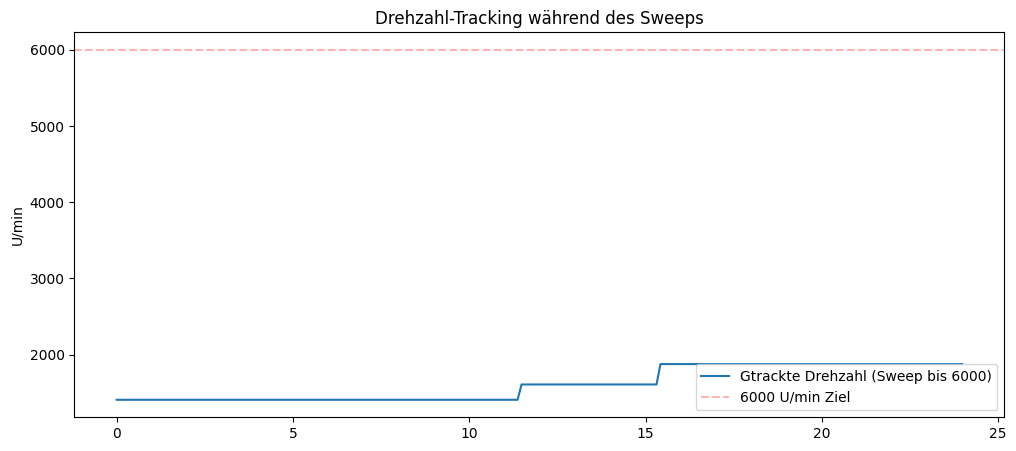

In [50]:
def extract_rpm_with_tracking(correlogram, lags_ms):
    rpms = []
    
    # Startwert finden (Durchschnitt der ersten 10 Frames im Leerlauf-Bereich)
    idx_start_search = np.argmin(np.abs(lags_ms - 40))
    idx_end_search = np.argmin(np.abs(lags_ms - 60))
    
    # Initialer Peak (Leerlauf)
    first_col = np.mean(correlogram[idx_start_search:idx_end_search, :10], axis=1)
    current_idx = np.argmax(first_col) + idx_start_search
    
    for step in range(correlogram.shape[1]):
        column = correlogram[:, step]
        
        # Suchfenster um den letzten bekannten Peak (ca. +/- 15ms)
        # Das erlaubt dem Algorithmus der Kurve zu folgen und Resonanzen zu ignorieren
        window_width = int(15 / (lags_ms[1] - lags_ms[0]))
        search_min = max(0, current_idx - window_width)
        search_max = min(len(column), current_idx + window_width)
        
        search_area = column[search_min:search_max]
        
        if len(search_area) > 0:
            # Wir suchen den Peak, der dem alten am nächsten ist UND stark ist
            peaks, _ = find_peaks(search_area, prominence=0.01)
            if len(peaks) > 0:
                # Nimm den Peak im Fenster
                local_idx = peaks[np.argmin(np.abs(peaks - (current_idx - search_min)))]
                current_idx = local_idx + search_min
            else:
                # Falls kein Peak im Fenster, bleibe kurzzeitig stabil
                pass 
        
        peak_lag_ms = lags_ms[current_idx]
        rpm = (60 * 1000) / peak_lag_ms
        
        # Plausibilitätscheck für 4-Zylinder (Zündfrequenz-Sprünge verhindern)
        if step > 0 and abs(rpm - rpms[-1]) > 500 and rpm > 2000:
             if abs(rpm/2 - rpms[-1]) < 500: rpm /= 2

        rpms.append(rpm)
        
    return pd.Series(rpms).interpolate().bfill().ffill().values

# Neue Berechnung
rpms_tracked = extract_rpm_with_tracking(corr_matrix, lags_ms)

# Visualisierung zur Kontrolle
plt.figure(figsize=(12, 5))
plt.plot(time_axis, rpms_tracked, label="Gtrackte Drehzahl (Sweep bis 6000)")
plt.axhline(6000, color='r', linestyle='--', alpha=0.3, label="6000 U/min Ziel")
plt.title("Drehzahl-Tracking während des Sweeps")
plt.ylabel("U/min")
plt.legend()
plt.show()